# HiRAG Retrieval q50 Case Studies

This notebook inspects individual queries from the q50 retrieval benchmark.

The aggregate notebook shows that `hi_minmax` improves bridge coverage most, but also increases bridge size. Here we look at concrete queries to understand where the strategies differ.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 80)

RUN_DIR_CANDIDATES = [
    Path(".runs/retrieval_eval/dev_retrieval_q50"),
    Path("../.runs/retrieval_eval/dev_retrieval_q50"),
]
RUN_DIR = next((path for path in RUN_DIR_CANDIDATES if path.exists()), RUN_DIR_CANDIDATES[0])
metrics = pd.read_csv(RUN_DIR / "metrics.csv")

contexts = []
with (RUN_DIR / "contexts.jsonl").open("r", encoding="utf-8") as handle:
    for line in handle:
        contexts.append(json.loads(line))
contexts = pd.DataFrame(contexts)

desired_variant_order = ["hi", "hi_weighted", "hi_minmax", "hi_minmax_budgeted", "hi_rerank", "hi_rerank_weighted"]
variant_order = [variant for variant in desired_variant_order if variant in metrics["variant"].unique()]
metrics.shape, contexts.shape

((250, 13), (250, 6))

## Find Query-Level Wins And Losses

A win here means a variant has higher bridge/query token overlap than baseline `hi` for the same query. This is only a proxy for answer quality, but it helps us find useful examples to read.

In [2]:
base = metrics[metrics.variant == "hi"].set_index("query")

def variant_delta(variant, metric="bridge_vs_query_overlap"):
    rows = metrics[metrics.variant == variant].set_index("query")
    joined = rows.join(base, lsuffix="", rsuffix="_hi")
    joined["delta"] = joined[metric] - joined[f"{metric}_hi"]
    return joined.reset_index().sort_values("delta", ascending=False)

minmax_query_overlap = variant_delta("hi_minmax", "bridge_vs_query_overlap")
minmax_query_overlap[["query", "delta", "bridge_vs_query_overlap", "bridge_vs_query_overlap_hi", "context_tokens", "context_tokens_hi", "bridge_path_edges", "bridge_path_edges_hi"]].head(10)

,query,delta,bridge_vs_query_overlap,bridge_vs_query_overlap_hi,context_tokens,context_tokens_hi,bridge_path_edges,bridge_path_edges_hi
49,What are the potential drawbacks of using plastic hive components in beekeeping?,0.428571,0.857143,0.428571,36309,32541,409,305
6,"What are the benefits of direct marketing for small farmers, as highlighted in the book?",0.285714,0.714286,0.428571,31354,29287,338,222
7,"Who is the series editor of ""Culture of the Land""?",0.200000,1.000000,0.800000,33331,29969,473,294
17,How does the book describe the influence of fertilizers on grass growth?,0.166667,0.833333,0.666667,34337,33545,526,352
2,"How does the Intervale in Burlington, Vermont, support new farmers?",0.166667,1.000000,0.833333,30852,26189,368,177
21,How does the book address the issue of grass tetany in livestock?,0.166667,0.666667,0.500000,31927,28219,354,231
3,What is the significance of the rest period in grass growth as described in the book?,0.142857,0.714286,0.571429,32710,29948,403,261
35,"What is the significance of soil organic matter in agriculture, as discussed in the book?",0.142857,0.857143,0.714286,34655,30449,399,231
24,How does the book address the relationship between soil health and climate change?,0.125000,0.750000,0.625000,30757,28251,306,210
8,Describe the role of the varroa mite in the decline of honey bee populations.,0.125000,0.625000,0.500000,29319,28757,273,213


In [3]:
minmax_query_overlap[["query", "delta", "bridge_vs_query_overlap", "bridge_vs_query_overlap_hi", "context_tokens", "context_tokens_hi", "bridge_path_edges", "bridge_path_edges_hi"]].tail(10)

,query,delta,bridge_vs_query_overlap,bridge_vs_query_overlap_hi,context_tokens,context_tokens_hi,bridge_path_edges,bridge_path_edges_hi
16,"What is the role of cover crops in farming, according to the book?",0.00,0.600000,0.600000,31021,30258,347,253
18,How does the Stametsian Model for Permaculture integrate mushrooms into sustainable agriculture?,0.00,0.375000,0.375000,33234,28996,297,212
19,How does a beekeeper typically control swarming in a colony?,0.00,0.800000,0.800000,35249,32341,352,259
20,"What is the ""Law of Return"" in agriculture, according to Howard?",0.00,1.000000,1.000000,37879,33503,573,350
22,What are the financial considerations for starting a market farming business?,0.00,0.666667,0.666667,34699,32459,398,284
23,"What is the central theme of ""Growing a Revolution: Bringing Our Soil Back to Life""?",0.00,0.666667,0.666667,39788,34014,531,357
1,What is the definition of a small farm according to the author?,0.00,0.750000,0.750000,24013,21018,183,120
26,What are the potential downsides of beekeeping as described in the book?,0.00,0.800000,0.800000,34913,31936,344,257
25,What are the three principles of conservation agriculture as outlined in the book?,0.00,0.833333,0.833333,36343,35773,531,402
47,What are some challenges faced by market farmers in terms of food safety?,-0.25,0.500000,0.750000,33118,30206,380,235


## Helper Functions For Reading A Query

The benchmark stores full contexts, selected entities, communities, and bridge edges. The helpers below print a compact view instead of dumping the whole 30k-token context.

In [4]:
def get_context(query, variant):
    row = contexts[(contexts["query"] == query) & (contexts["variant"] == variant)]
    if row.empty:
        raise KeyError((query, variant))
    return row.iloc[0].to_dict()

def get_metrics(query, variant):
    row = metrics[(metrics["query"] == query) & (metrics["variant"] == variant)]
    if row.empty:
        raise KeyError((query, variant))
    return row.iloc[0].to_dict()

def compact_edges(edges, n=12):
    rows = []
    for edge in edges[:n]:
        rows.append({
            "source": edge.get("source"),
            "target": edge.get("target"),
            "rank": edge.get("rank"),
            "semantic_score": edge.get("semantic_score"),
            "cost": edge.get("cost"),
            "description": edge.get("description", "")[:180],
        })
    return pd.DataFrame(rows)

def compare_query(query, variants=("hi", "hi_minmax", "hi_rerank_weighted")):
    metric_rows = []
    for variant in variants:
        m = get_metrics(query, variant)
        metric_rows.append({
            "variant": variant,
            "context_tokens": m["context_tokens"],
            "bridge_edges": m["bridge_edge_count"],
            "path_edges": m["bridge_path_edges"],
            "query_overlap": m["bridge_vs_query_overlap"],
            "local_recall": m["bridge_vs_local_recall"],
            "global_recall": m["bridge_vs_global_recall"],
            "latency": m["latency_seconds"],
        })
    return pd.DataFrame(metric_rows)

def selected_entities(query, variant, n=20):
    return pd.DataFrame({"entity": get_context(query, variant)["selected_entities"][:n]})

## Example 1: Strong Minmax Win

This query had one of the largest bridge/query-overlap improvements for `hi_minmax`.

In [5]:
win_query = minmax_query_overlap.iloc[0]["query"]
win_query

'What are the potential drawbacks of using plastic hive components in beekeeping?'

In [6]:
compare_query(win_query)

,variant,context_tokens,bridge_edges,path_edges,query_overlap,local_recall,global_recall,latency
0,hi,32541,271,305,0.428571,0.679245,0.372425,0.045476
1,hi_minmax,36309,378,409,0.857143,0.698113,0.402536,11.910823
2,hi_rerank_weighted,32132,261,271,0.714286,0.601562,0.386943,0.693976


In [7]:
pd.concat(
    {
        "hi": selected_entities(win_query, "hi"),
        "hi_minmax": selected_entities(win_query, "hi_minmax"),
        "hi_rerank_weighted": selected_entities(win_query, "hi_rerank_weighted"),
    },
    axis=1,
)

,hi,hi_minmax,hi_rerank_weighted
,entity,entity,entity
0,"""ORGANIC HIVE-MANAGEMENT TECHNIQUES""","""ORGANIC HIVE-MANAGEMENT TECHNIQUES""","""SUPERS"""
1,"""COMMERCIAL BEESWAX""","""COMMERCIAL BEESWAX""","""FRAME LIFTER"""
2,"""WAX WORMS""","""WAX WORMS""","""HIVE MANAGEMENT TECHNIQUES"""
3,"""BCHS""","""BCHS""","""STANDARD HIVE TOOL"""
4,"""FRAME LIFTER""","""FRAME LIFTER""","""BEE-GO"""
5,"""FOAM INSULATION""","""FOAM INSULATION""","""TEN-FRAME HIVE BODY"""
6,"""INDUSTRIAL MODEL OF BEEKEEPING""","""INDUSTRIAL MODEL OF BEEKEEPING""","""HIVE MANAGEMENT"""
7,"""BEE PATHOGENS""","""BEE PATHOGENS""","""ORGANIC HIVE-MANAGEMENT TECHNIQUES"""
8,"""BEEKEEPING: A PRACTICAL GUIDE""","""BEEKEEPING: A PRACTICAL GUIDE""","""WOOD"""


In [8]:
compact_edges(get_context(win_query, "hi")["bridge_edges"], n=10)

,source,target,rank,semantic_score,cost,description
0,"""NORTH AMERICA""","""UNITED STATES""",369,None,None,"""United States is in North America."""
1,"""BEEKEEPING""","""UNITED STATES""",363,None,None,"""was a widespread agricultural endeavor in"""
2,"""UNITED STATES""","""USDA""",350,None,None,"""USDA collects data on US markets""<SEP>""USDA is located in/operates in the United States.""<SEP>""USDA is the US Department of Agriculture..."
3,"""AMERICA""","""UNITED STATES""",350,None,None,"""United States is America.""<SEP>""are the same entity""<SEP>""is synonymous with"""
4,"""HONEY""","""UNITED STATES""",314,None,None,"""Honey is produced in the United States.""<SEP>""There are over 300 types of honey in the United States."""
5,"""UNITED STATES""","""VARROA""",309,None,None,"""became established in the United States"""
6,"""NEW YORK""","""UNITED STATES""",307,None,None,"""contains""<SEP>""state in"""
7,"""UNITED STATES""","""VERMONT""",299,None,None,"""VERMONT is located in the UNITED STATES."""
8,"""UNITED STATES""","""VARROA MITE""",290,None,None,"""Varroa mite is present in the United States.""<SEP>""Varroa mite was first spotted in the United States in 1987.""<SEP>""found in""<SEP>""ser..."
9,"""BEEKEEPING INDUSTRY""","""UNITED STATES""",288,None,None,"""operates within"""


In [9]:
compact_edges(get_context(win_query, "hi_minmax")["bridge_edges"], n=10)

,source,target,rank,semantic_score,cost,description
0,"""BEEKEEPING""","""UNITED STATES""",363,0.452354,0.682230,"""was a widespread agricultural endeavor in"""
1,"""UNITED STATES""","""USDA""",350,-0.049403,1.174568,"""USDA collects data on US markets""<SEP>""USDA is located in/operates in the United States.""<SEP>""USDA is the US Department of Agriculture..."
2,"""HONEY""","""UNITED STATES""",314,0.451696,0.662856,"""Honey is produced in the United States.""<SEP>""There are over 300 types of honey in the United States."""
3,"""UNITED STATES""","""VARROA""",309,0.421801,0.693033,"""became established in the United States"""
4,"""NEW YORK""","""UNITED STATES""",307,0.048563,1.062941,"""contains""<SEP>""state in"""
5,"""UNITED STATES""","""VARROA MITE""",290,0.404881,0.699671,"""Varroa mite is present in the United States.""<SEP>""Varroa mite was first spotted in the United States in 1987.""<SEP>""found in""<SEP>""ser..."
6,"""UNITED STATES""","""VARROA DESTRUCTOR""",290,0.472267,0.632665,"""Korean mites spread to the United States.""<SEP>""cause of honey bee mortality across""<SEP>""identified in hives located in"""
7,"""BEEKEEPING INDUSTRY""","""UNITED STATES""",288,0.486167,0.623346,"""operates within"""
8,"""AUSTRALIA""","""UNITED STATES""",288,0.079330,1.030183,"""Australia has similar property worship to the US."""
9,"""FLORIDA""","""UNITED STATES""",283,0.419146,0.685992,"""contains"""


Reading prompt: compare whether minmax is adding genuinely query-relevant bridge edges or merely adding more path text. If it helps because it finds better intermediate concepts, that supports budgeted minmax as the next implementation.

## Example 2: Minmax Loss Or No-Gain Case

This query is useful because it shows where minmax does not improve query overlap. These are the cases that tell us what budget/penalty to add.

In [10]:
loss_query = minmax_query_overlap.iloc[-1]["query"]
loss_query

'What are some challenges faced by market farmers in terms of food safety?'

In [11]:
compare_query(loss_query)

,variant,context_tokens,bridge_edges,path_edges,query_overlap,local_recall,global_recall,latency
0,hi,30206,197,235,0.75,0.590164,0.364650,0.043851
1,hi_minmax,33118,275,380,0.50,0.622951,0.401274,9.940976
2,hi_rerank_weighted,27151,132,172,0.50,0.471831,0.369686,0.853052


In [12]:
compact_edges(get_context(loss_query, "hi")["bridge_edges"], n=12)

,source,target,rank,semantic_score,cost,description
0,"""AGRICULTURE""","""UNITED STATES""",422,None,None,"""Americans are ignorant of dependence on farming.""<SEP>""Has agricultural subsidies that incentivize practices degrading soil health.""<SE..."
1,"""NORTH AMERICA""","""UNITED STATES""",369,None,None,"""United States is in North America."""
2,"""CALIFORNIA""","""UNITED STATES""",359,None,None,"""CALIFORNIA is located in the UNITED STATES.""<SEP>""California is a state in the United States.""<SEP>""California is in the United States...."
3,"""UNITED STATES""","""USDA""",350,None,None,"""USDA collects data on US markets""<SEP>""USDA is located in/operates in the United States.""<SEP>""USDA is the US Department of Agriculture..."
4,"""AMERICA""","""UNITED STATES""",350,None,None,"""United States is America.""<SEP>""are the same entity""<SEP>""is synonymous with"""
5,"""CHINA""","""UNITED STATES""",318,None,None,"""exports honey to"""
6,"""NEW YORK""","""UNITED STATES""",307,None,None,"""contains""<SEP>""state in"""
7,"""UNITED STATES""","""VIRGINIA""",295,None,None,"""state in the United States"""
8,"""SUSTAINABLE AGRICULTURE""","""UNITED STATES""",290,None,None,"""Sustainable agriculture produces 5-8% of food in the US."""
9,"""BEEKEEPING INDUSTRY""","""UNITED STATES""",288,None,None,"""operates within"""


In [13]:
compact_edges(get_context(loss_query, "hi_minmax")["bridge_edges"], n=12)

,source,target,rank,semantic_score,cost,description
0,"""AGRICULTURE""","""UNITED STATES""",422,0.357410,0.794152,"""Americans are ignorant of dependence on farming.""<SEP>""Has agricultural subsidies that incentivize practices degrading soil health.""<SE..."
1,"""NORTH AMERICA""","""UNITED STATES""",369,0.184970,0.947804,"""United States is in North America."""
2,"""CALIFORNIA""","""UNITED STATES""",359,0.202454,0.925972,"""CALIFORNIA is located in the UNITED STATES.""<SEP>""California is a state in the United States.""<SEP>""California is in the United States...."
3,"""UNITED STATES""","""USDA""",350,0.154444,0.970721,"""USDA collects data on US markets""<SEP>""USDA is located in/operates in the United States.""<SEP>""USDA is the US Department of Agriculture..."
4,"""AMERICA""","""UNITED STATES""",350,0.076783,1.049349,"""United States is America.""<SEP>""are the same entity""<SEP>""is synonymous with"""
5,"""UNITED STATES""","""VARROA DESTRUCTOR""",290,0.157817,0.947115,"""Korean mites spread to the United States.""<SEP>""cause of honey bee mortality across""<SEP>""identified in hives located in"""
6,"""INDUSTRIAL AGRICULTURE""","""UNITED STATES""",290,0.323272,0.782750,"""dominant throughout""<SEP>""influential in"""
7,"""SUSTAINABLE AGRICULTURE""","""UNITED STATES""",290,0.370098,0.739233,"""Sustainable agriculture produces 5-8% of food in the US."""
8,"""BEEKEEPING INDUSTRY""","""UNITED STATES""",288,0.248837,0.860675,"""operates within"""
9,"""KING""","""UNITED STATES""",283,0.268445,0.837703,"""King was concerned about the future of the United States."""


## Reranking Changes The Seed Entities

The reranker variants often shorten the bridge, but reduce bridge/local recall. This section finds queries where `hi_rerank_weighted` changes bridge size the most.

In [14]:
rerank_edges = variant_delta("hi_rerank_weighted", "bridge_edge_count")
rerank_edges[["query", "delta", "bridge_edge_count", "bridge_edge_count_hi", "bridge_vs_query_overlap", "bridge_vs_query_overlap_hi"]].head(8)

,query,delta,bridge_edge_count,bridge_edge_count_hi,bridge_vs_query_overlap,bridge_vs_query_overlap_hi
24,How does the book address the relationship between soil health and climate change?,132,295,163,0.750000,0.625000
4,What innovative practices does Greensgrow Farm in Philadelphia employ to make urban farming sustainable?,99,286,187,0.700000,0.700000
45,How does the author suggest managing machinery on a small farm?,93,190,97,0.666667,0.666667
43,"What role do mushrooms play in the environment, particularly in terms of waste decomposition?",84,265,181,0.375000,0.375000
23,"What is the central theme of ""Growing a Revolution: Bringing Our Soil Back to Life""?",71,361,290,0.666667,0.666667
35,"What is the significance of soil organic matter in agriculture, as discussed in the book?",56,269,213,0.857143,0.714286
36,What role does agriculture play in environmental sustainability according to the book?,54,218,164,0.666667,0.666667
44,How does the book define sustainability?,50,159,109,0.666667,0.666667


In [15]:
rerank_edges[["query", "delta", "bridge_edge_count", "bridge_edge_count_hi", "bridge_vs_query_overlap", "bridge_vs_query_overlap_hi"]].tail(8)

,query,delta,bridge_edge_count,bridge_edge_count_hi,bridge_vs_query_overlap,bridge_vs_query_overlap_hi
6,"What are the benefits of direct marketing for small farmers, as highlighted in the book?",-57,117,174,0.714286,0.428571
7,"Who is the series editor of ""Culture of the Land""?",-59,156,215,0.800000,0.800000
21,How does the book address the issue of grass tetany in livestock?,-64,92,156,0.500000,0.500000
47,What are some challenges faced by market farmers in terms of food safety?,-65,132,197,0.500000,0.750000
37,What is the significance of crop rotation in sustainable farming?,-76,188,264,0.800000,0.800000
3,What is the significance of the rest period in grass growth as described in the book?,-79,130,209,0.714286,0.571429
25,What are the three principles of conservation agriculture as outlined in the book?,-98,242,340,0.833333,0.833333
14,"How does Growing Gardens support home gardeners in Portland, Oregon?",-101,121,222,0.714286,0.714286


In [16]:
compact_query = rerank_edges.iloc[-1]["query"]
compact_query

'How does Growing Gardens support home gardeners in Portland, Oregon?'

In [17]:
compare_query(compact_query, variants=("hi", "hi_rerank", "hi_rerank_weighted"))

,variant,context_tokens,bridge_edges,path_edges,query_overlap,local_recall,global_recall,latency
0,hi,30812,222,291,0.714286,0.727273,0.406408,0.044889
1,hi_rerank,26007,118,168,0.714286,0.677966,0.360902,0.449589
2,hi_rerank_weighted,26164,121,168,0.714286,0.686441,0.388471,0.597810


In [18]:
pd.concat(
    {
        "hi": selected_entities(compact_query, "hi"),
        "hi_rerank": selected_entities(compact_query, "hi_rerank"),
        "hi_rerank_weighted": selected_entities(compact_query, "hi_rerank_weighted"),
    },
    axis=1,
)

,hi,hi_rerank,hi_rerank_weighted
,entity,entity,entity
0,"""PORTLAND'S WATER BUREAU""","""PORTLAND'S WATER BUREAU""","""PORTLAND'S WATER BUREAU"""
1,"""SCHOOL GARDEN WIZARD""","""MONIQUE""","""MONIQUE"""
2,"""THE HOME GARDENING PROJECT FOUNDATION""","""THE HOME GARDENING PROJECT FOUNDATION""","""THE HOME GARDENING PROJECT FOUNDATION"""
3,"""BERKELEY STREET COMMUNITY GARDEN""","""YOUTH GROW""","""YOUTH GROW"""
4,"""TRICYCLE GARDENS""","""VICTORY GARDEN ERA""","""VICTORY GARDEN ERA"""
5,"""BLETHEN""","""GREEN THUMB""","""GREEN THUMB"""
6,"""COMMUNITY GARDENING""","""GROWING TOGETHER""","""GROWING TOGETHER"""
7,"""GREEN THUMB""","""DEBRA LIPPOLDT""","""DEBRA LIPPOLDT"""
8,"""YOUTH GROW""","""DURHAM INNER-CITY GARDENERS""","""DURHAM INNER-CITY GARDENERS"""


## Query-Level Heatmap

This heatmap shows per-query bridge/query-overlap deltas versus baseline. Blue means the variant improved the deterministic query-overlap proxy; red means it got worse.

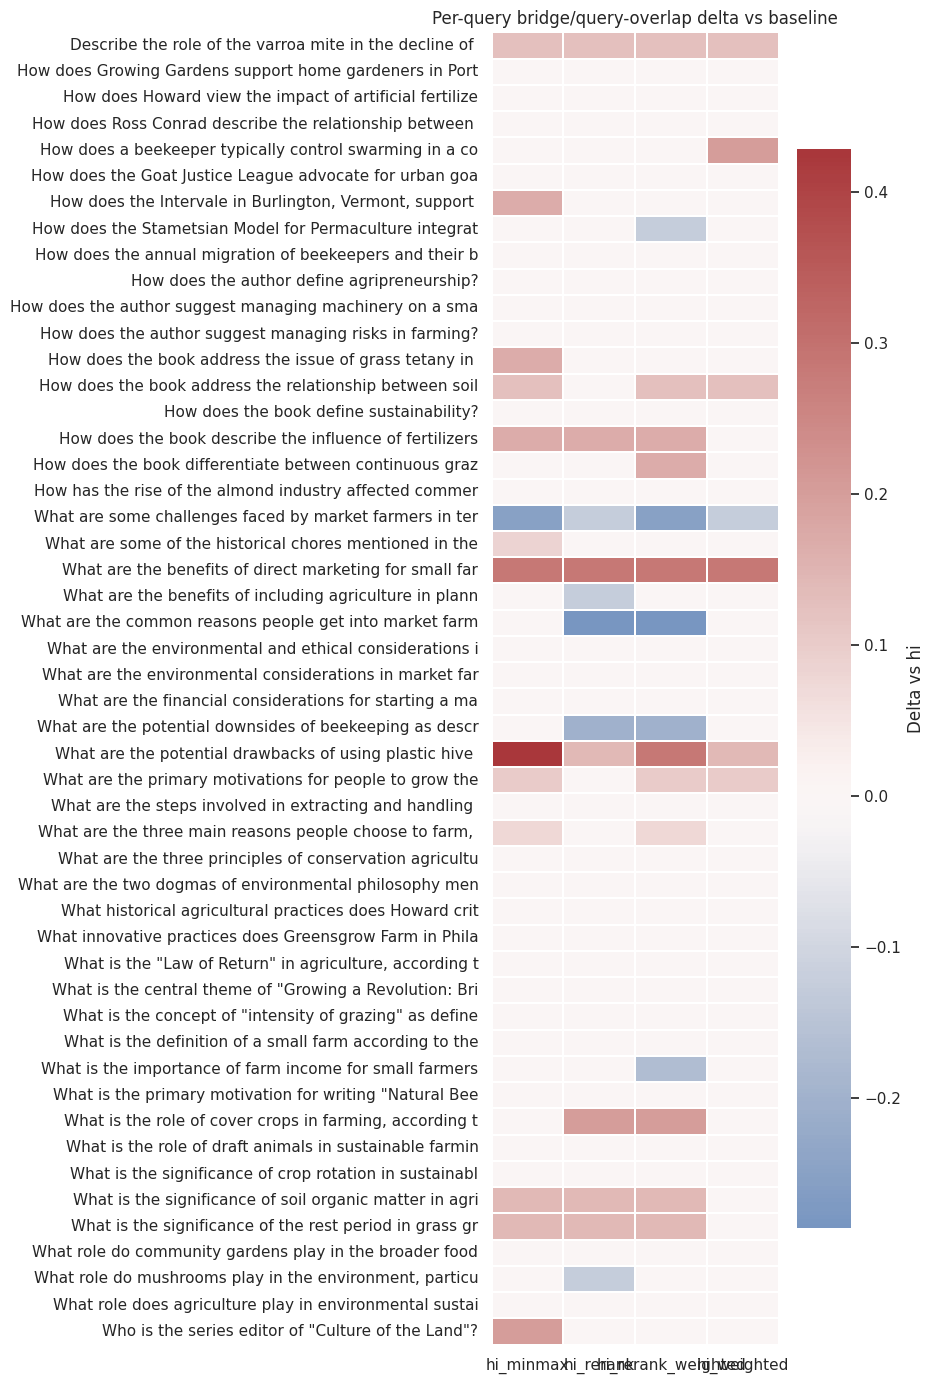

In [19]:
heat = []
for variant in variant_order[1:]:
    d = variant_delta(variant, "bridge_vs_query_overlap")
    d["short_query"] = d["query"].str.slice(0, 55)
    heat.append(d[["short_query", "variant", "delta"]])
heat = pd.concat(heat)
pivot = heat.pivot_table(index="short_query", columns="variant", values="delta", aggfunc="first")

plt.figure(figsize=(9, 14))
sns.heatmap(pivot, center=0, cmap="vlag", linewidths=0.2, cbar_kws={"label": "Delta vs hi"})
plt.title("Per-query bridge/query-overlap delta vs baseline")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## How To Use This Notebook For The Report

Use the aggregate notebook for the main quantitative story, then use this notebook to choose 2-3 representative examples:

1. A minmax win where the path clearly picks better intermediate concepts.
2. A minmax no-gain/loss where the path gets long without helping.
3. A reranking case where the seed entities visibly change.

These examples make the project easier to explain than metrics alone.

## Budgeted And Answer-Level Follow-Up

New runs may include `hi_minmax_budgeted`. The case-study helpers filter `variant_order` to variants present in the loaded metrics, so old q50 artifacts still render while newer budgeted sweeps can be compared in the same notebook. Pair qualitative cases with `.runs/answer_eval/.../answers.jsonl` and judge summaries when selecting examples for the report.
